---
## **1. Introduction & Set Up**

#### **1.1. Import Necessary Libaries/Packages**

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd
import sys
from huggingface_hub import login
from datasets import load_dataset, DatasetDict, concatenate_datasets
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

#### **1.2. Load Datasets**

In [9]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
val_df = pd.read_csv('val.csv')

#### **1.3. Label Mapping**

In [10]:
label_map = {'FAVOR': 0, 'NONE': 1, 'AGAINST': 2}

for df in [train_df, val_df, test_df]:
    df['label'] = df['Stance'].map(label_map)

print("Label distribution (train):")
print(train_df['Stance'].value_counts())

Label distribution (train):
Stance
AGAINST    1143
NONE        534
FAVOR       483
Name: count, dtype: int64


#### **1.4. Class Distribution Plot**

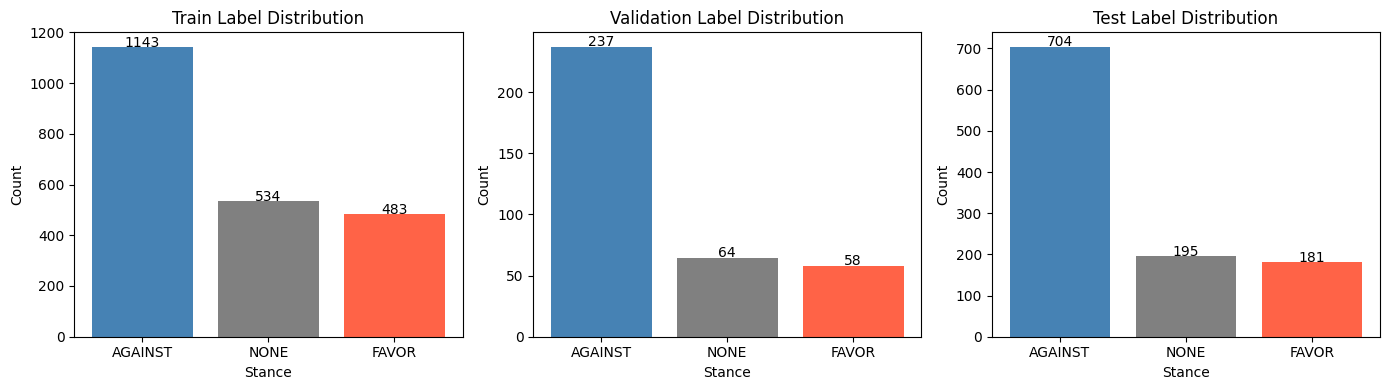

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}

for ax, (name, df) in zip(axes, splits.items()):
    counts = df['Stance'].value_counts()
    ax.bar(counts.index, counts.values, color=['steelblue', 'gray', 'tomato'])
    ax.set_title(f'{name} Label Distribution')
    ax.set_xlabel('Stance')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()